In [1]:
import os
import re
import csv
import json
import subprocess

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from Bio import AlignIO

## Generating dataframes and graphs for NFIL3 conservation analysis

### For disorder with AIUPred

In [2]:
# First obtain the AIUPRED output JSON file, and put it in the right folder
path_AIUPred = "../example_data/NFIL3/AIUPred/AIUPred_mNFIL3.json"

with open(path_AIUPred, "r") as f:
    data_AIUPred = json.load(f)
    
aiupred = data_AIUPred["aiupred"]
aiupred_pct = [values * 100 for values in aiupred]

### For the pLDDT with AF3

In [3]:
def find_files_AF3(directory, number_models=5):
    """
    Generates a JSON file path list for a specified number of models in a specified base path.
    
    Parameters:
        - directory (str): The default directory where the JSON files for the models are stored
        - number_models (int): number of structural models
    Returns:
        - json_files (list): List of full paths to the JSON files
    """

    # Run "select_plddt_CA.sh" must be in the right directory
    bash_directory = directory.replace("C:/", "/mnt/c/")
    subprocess.run(["bash", "../selec_plDDT_CA.sh", f"{bash_directory}"], capture_output=True, text=True)

    name = os.path.splitext(os.path.basename(directory))[0]
    json_files = [f"{directory}/{name}_model_{model}_result.json" for model in range(number_models)]
    return json_files
    

In [4]:
def merge_json_AF3(directory, input_files, key, output_file="merged_AF3.json"):
    """
    Merges multiple JSON files into a single file by calculating the average of the key values.
    
    Parameters:
        - directory (str): Path to the directory containing the JSON files
        - input_files (list): List of JSON files to merge
        - key (str): key to average
    Returns:
        - output_file (dict): Dictionary containing the averages
    """

    # Opening Files
    all_plddt = []
    for file in input_files:
        with open(file, "r") as f:
            data = json.load(f)      
        all_plddt.append(data[key])
    
    # Conversion to an array and calculation of the average by residue
    all_plddt = np.array(all_plddt)
    mean_plddt = np.mean(all_plddt, axis=0)
    
    # Use a reference file for the other indexes
    with open(input_files[0], "r") as f:
        ref_data = json.load(f)

    # Creating the dictionary
    output = {
        "nbr_res": ref_data["nbr_res"],
        "number_atoms": ref_data["number_atoms"],
        f"{key}_mean": mean_plddt.tolist()
    }
    
    # Output file path
    output_path = os.path.join(directory, output_file)

    # Saving data to a file
    with open(output_path, "w") as f:
        json.dump(output, f, indent=4)

    print(f"{key} averaged and saved in: {directory}/{output_file}")


#### Main pLDDT

In [5]:
path_plddt = "../example_data/NFIL3/fold_mnfil3"
json_files_AF3 = find_files_AF3(path_plddt)

key = "plDDT"
merge_json_AF3(path_plddt, json_files_AF3, key)

with open(f"{path_plddt}/merged_AF3.json", "r") as f:
    data_merged = json.load(f)

plddt_af3_av = data_merged[f"{key}_mean"]

plDDT averaged and saved in: ../example_data/NFIL3/fold_mnfil3/merged_AF3.json


### Alignment statistics (quality, conservation and consensus) with Jalview

In [6]:
def process_files(json_file_path, csv_file_path):
    """
    Extract the relevant values (quality, consensus and conservation) from .json and .csv files generated by Jalview.

    Parameters:
        - json_file_path (str): .json file generated by Jalview
        - csv_file_path (str): .csv file generated by Jalview
    Returns:
        - updated_data (list): Output list containing the relevant values
    """
    
    with open(json_file_path, "r") as f:
        data_align = json.load(f)

    quality_values = []
    consensus_values = []
    conservation_values = []
    
    with open(csv_file_path, "r") as f:
        for line in f:
            if line.startswith("Quality,"):
                # Extract the values after "Quality,"
                quality_values = [float(value) for value in line.strip().split(",")[1:] if value.strip()]
            elif line.startswith("Consensus%,"):
                # Extract the values after "Consensus%,"
                # NOTE: Check if the column header is "Consensus%"; if not, add "%" to the first row labeled "Consensus" in the .csv file.
                consensus_values = [float(value) for value in line.strip().split(",")[1:] if value.strip()]
            elif line.startswith("Conservation,"):
                # Extract the values after "Conservation,"
                conservation_values = [float(value) for value in line.strip().split(",")[1:] if value.strip()]
    
    # Modifier les séquences et les valeurs dans "Quality"
    updated_data = {"name":[], "seq":[], "num":[], "longueur":[], "Conservation":[], "Quality":[], "Consensus%":[]}

    for entry in data_align["seqs"]:
        seq = entry["seq"]
        name = entry["name"]

        # Remove the gaps ("-") from seq and the corresponding values in "Quality"
        new_seq = ""
        new_quality = []
        new_consensus = []
        new_conservation = []
        num=[]

        tour = 0
        for i, char in enumerate(seq):      
            if char != "-":
                tour = tour + 1
                new_seq += char
                num.append(tour)
                new_quality.append(quality_values[i])
                new_consensus.append(consensus_values[i])
                new_conservation.append(conservation_values[i])


        # Add the length of the new sequence
        seq_length = len(new_seq)
        
        # Update the list of sequences
        updated_data["name"].append(name)
        updated_data["seq"].append(new_seq)
        updated_data["num"].append(num)
        updated_data["longueur"].append(seq_length)
        updated_data["Conservation"].append(new_conservation)
        updated_data["Quality"].append(new_quality)
        updated_data["Consensus%"].append(new_consensus)

    return updated_data
    

#### Main statistics

In [7]:
# NOTE: Obtain the "jalview_files.json" file using the "Files/Output to Textbox" tab in the Jalview tool.
# NOTE: Obtain the "jalview_annotation.csv" file using the "Files/Export Annotations..." tab in the Jalview tool.
# AND check whether to add the "%" to the first "Consensus" index in the .csv file!

path_jalview = "../example_data/NFIL3/Jalview/jalview_"
result = process_files(f"{path_jalview}files.json", f"{path_jalview}annotations.csv")

with open(f"{path_jalview}output.json", "w") as output_file:
     json.dump(result, output_file, indent=4)

with open(f"{path_jalview}output.json", "r") as f:
    data_output = json.load(f)
    
quality = data_output["Quality"][0]
max_quality = max(quality) # NOTE: only if you have at least one perfectly aligned residue
quality_pct = [(i/max_quality)*100 for i in quality]

conservation = data_output["Conservation"][0]
conservation_pct = [(i/11)*100 for i in conservation]

consensus = data_output["Consensus%"][0]

### Omega report (conservation pressure: BEB prob w<1)

In [8]:
def get_aligned(aligned_fasta, reference_index=0):
    """
    Returns a dictionary that maps the positions of the residues in an aligned reference sequence to their corresponding positions in the unaligned reference sequence:
    aligned_position (1-based) -> ref_pos (1-based, without gaps)
    
    Parameters:
        - aligned_fasta (str): Path to the aligned fasta file
        - reference_index (int): Index of the reference sequence in the alignment (default: 0)
    Returns:
        - mapping (dict): Dictionary mapping aligned positions to reference positions
    """
    
    alignment = AlignIO.read(aligned_fasta, "fasta")
    ref_seq = alignment[reference_index].seq

    ref_pos = 0
    aligned_index = 0
    mapping = {}

    for col_idx in range(alignment.get_alignment_length()):
        column = alignment[:, col_idx]

        if "-" in column:
            if ref_seq[col_idx] != "-":
                ref_pos += 1
            continue

        ref_pos += 1
        aligned_index += 1
        mapping[aligned_index] = ref_pos

    return mapping


In [9]:
def extract_beb_to_csv(aligned_fasta, rst_file, output_csv):
    """
    Extracts the BEB probabilities from the EasyCodeML rst file, and adds the position of the reference sequence into a CSV file.
    
    Parameters:
        - aligned_fasta (str): Path to the aligned fasta file
        - rst_file (str): Path to the EasyCodeML rst file
    Returns:
        - output_csv (str): Name of the CSV file
    """

    # Mapping aligned_position -> ref_pos
    aligned_ref_pos = get_aligned(aligned_fasta)

    # Reading the rst file
    with open(rst_file, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()

    # Search for the BEB section
    start = None
    for i, line in enumerate(lines):
        if "Bayes Empirical Bayes (BEB)" in line:
            start = i
            break

    # Data extraction
    pattern = re.compile(
        r"""^\s*
        (\d+)                           # position
        \s+([A-Z\*-])                   # amino acid
        \s+((?:[\d\.]+\s+){10}[\d\.]+)  # 11 probalities
        \s+\(\s*(\d+)\s*\)              # most probable class
        \s+([\d\.]+)                    # mean_w
        \s*\+\-\s*                      # +-
        ([\d\.]+)                       # SD
        """,
        re.VERBOSE
    )

    data = []
    for line in lines[start:-1]:
        m = pattern.match(line)
        if m:
            aligned_pos = int(m.group(1))
            aa = m.group(2)

            best_class = int(m.group(4))
            mean_w = float(m.group(5))
            sd_w = float(m.group(6)) 
            
            probs = list(map(float, m.group(3).split()))
            pr_w_conservation = probs[0]
            best_pr = probs[best_class - 1]
            pr_w_selection = probs[10]
            
            ref_pos = aligned_ref_pos.get(aligned_pos, "")
             
            data.append([
                aligned_pos,
                ref_pos,
                aa,
                pr_w_conservation,
                best_pr,
                pr_w_selection,
                best_class,
                mean_w,
                sd_w
            ])

    # Writing the output CSV file
    with open(output_csv, "w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow([
            "site",
            "sequence position",
            "residue",
            "BEB prob classe 1",
            "Best BEB prob",
            "BEB prob classe 11",
            "Best class",
            "Postmean w",
            "SD w"
        ])
        writer.writerows(data)

    print(f"Generated CSV file in: {output_csv}")
    print(f"Number of sites extracted: {len(data)}")


#### Main Omega

In [10]:
path_omega = "../example_data/NFIL3/CodeML"
fasta_file = f"{path_omega}/alignement_nfil3_prot_vertebre_without_PM_OA_PS.fasta"
rst_file = f"{path_omega}/M8/rst"
csv_omega = f"{path_omega}/M8_site_probs.csv"

extract_beb_to_csv(fasta_file, rst_file, csv_omega)
df_omega = pd.read_csv(csv_omega)

Generated CSV file in: ../example_data/NFIL3/CodeML/M8_site_probs.csv
Number of sites extracted: 280


### Full Dataframe

In [11]:
def create_df(path, save_path):
    # Search for the original sequence
    seq = os.path.splitext(os.path.basename(path))[0]
    file_seq = path+"/"+seq+"_job_request"

    with open(f"{file_seq}.json", "r") as f:
        data_seq = json.load(f)

    sequence = data_seq[0]["sequences"][0]["proteinChain"]["sequence"]
    
    # Create a complete DataFrame containing all the positions of the residues
    df_beb = pd.DataFrame({"position": range(1, len(sequence) + 1), "residue": list(sequence)})
    res_pos = df_beb["position"]
    res_name = df_beb["residue"]

    # Set the columns to 0 
    df_beb["BEB prob classe 1"] = ""
    df_beb["Postmean w"] = 0
    df_beb["SD w"] = 0

    # Enter the BEB values for the corresponding positions and residues
    for _, row in df_omega.iterrows():
        pos = row["sequence position"]
        res = row["residue"]
        prob = row["BEB prob classe 1"]
        mean = row["Postmean w"]
        sd = row["SD w"]
        if pos <= len(sequence) and df_beb.at[pos-1, "residue"] == res:
            df_beb.at[pos-1, "BEB prob classe 1"] = prob
            df_beb.at[pos-1, "Postmean w"] = mean
            df_beb.at[pos-1, "SD w"] = sd

    BEB_classe1 = df_beb["BEB prob classe 1"].replace("", np.nan).astype(float)
    postmean_w = df_beb["Postmean w"].replace(0, np.nan)
    sd_w = df_beb["SD w"].replace(0, np.nan)
    
    # Create the dataframe
    df = []
    df = pd.DataFrame({
        "Position": res_pos,
        "Name": res_name,
        "AIUPred": aiupred_pct,
        "pLDDT": plddt_af3_av,
        "Quality": quality_pct,
        "Conservation": conservation_pct,
        "Consensus": consensus,
        "BEB classe 1": BEB_classe1,
        "Postmean W": postmean_w,
        "sd W": sd_w
    })
    
    # Save the dataframe
    
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    df.to_csv(f"{save_path}/data_mNFIL3.csv", sep=";", index=False, encoding="utf-8")
    
    return df

In [12]:
path_df = "../example_data/NFIL3/fold_mnfil3"
save_path = "../example_data/NFIL3/Results"

df_all = create_df(path_df, save_path)
df_all

C:\Users\e216138h\AppData\Local\Temp\ipykernel_24104\1069270148.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.05' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_beb.at[pos-1, "Postmean w"] = mean
C:\Users\e216138h\AppData\Local\Temp\ipykernel_24104\1069270148.py:31: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.001' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_beb.at[pos-1, "SD w"] = sd
C:\Users\e216138h\AppData\Local\Temp\ipykernel_24104\1069270148.py:33: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', T

,Position,Name,AIUPred,pLDDT,Quality,Conservation,Consensus,BEB classe 1,Postmean W,sd W
0,1,M,57.874376,33.18,34.672167,0.000000,71.641790,NaN,NaN,NaN
1,2,Q,65.218540,58.83,20.680179,0.000000,70.149254,NaN,NaN,NaN
2,3,L,63.766020,49.67,31.796843,0.000000,70.149254,NaN,NaN,NaN
3,4,R,60.909504,30.78,35.141755,27.272727,70.149254,NaN,NaN,NaN
4,5,K,61.483000,51.13,29.303424,9.090909,67.164180,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
457,458,A,27.852560,71.04,59.521138,18.181818,76.119400,NaN,NaN,NaN
458,459,S,32.309112,68.60,45.293578,0.000000,79.104480,NaN,NaN,NaN
459,460,D,39.701600,58.54,60.107080,27.272727,80.597015,NaN,NaN,NaN
460,461,S,45.656210,59.18,65.930016,27.272727,89.552240,NaN,NaN,NaN


#### Plot Dataframe

In [13]:
def plot_all(df, name, save_path, plot="plot", save="png"):
    """
    Plot one or more columns of a dataframe.
    
    Parameters:
        - df (DataFrame): Dataframe containing the values to be plotted
        - name (str): Name of one or more column headers
        - save_path (str): Path to the plot backup
        - plot (str): Graph type (plot or fill)
        - save (str): File plot format (PDF or PNG)
    """
    
    # Extract headers and remove spaces
    y_cols = name.split(",")
    y_cols = [col.strip() for col in y_cols]
    
    # Column validation
    y_cols_val = []
    for col in y_cols:
        if col in df.columns:
            y_cols_val.append(col)
        else:
            print(f"Column {col} doesn't exist, it has been ignored.")

    # Setting the variables for the plot
    all_res = []
    all_res.extend(df["Position"])
    xmin, xmax = min(all_res), max(all_res)
    name = name.replace(", ", "_")
    name = name.replace(" ", "")
    
    # Plot
    plt.figure(figsize=(30, 10), dpi=300)
    # c="#1f77b4", c="#d62728", c="#800080", c="#ff7f0e"
    
    for col in y_cols_val:
        if plot == "plot":
            if col == "BEB classe 1":
                df["BEB classe 1 %"] = [i*100 for i in df["BEB classe 1"]]
                plt.plot(df["Position"], df["BEB classe 1 %"], label="BEB classe 1 %", linewidth=2)
            else:
                plt.plot(df["Position"], df[col], label=col, linewidth=2)
        elif plot == "fill":
            if col == "BEB classe 1":
                df["BEB classe 1 %"] = [i*100 for i in df["BEB classe 1"]]
                plt.fill_between(df["Position"], df["BEB classe 1 %"], label="BEB classe 1 %", linewidth=2, alpha=0.4)
            else:
                plt.fill_between(df["Position"], df[col], label=col, linewidth=2, alpha=0.4)
        else:
            print("Please specify the type of graph you want: 'plot' or 'fill'.")
        
    plt.title("Scores for NFIL3 mouse ", fontsize=16)
    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)
    plt.grid(color="0.9", linestyle="-", linewidth=0.5)
    plt.ylim(-5, 105)
    plt.yticks(np.linspace(0, 100, 5))
    plt.xticks(np.arange(xmin, xmax + 1, 50))
    plt.xlabel("Residues positions", fontsize=12)
    plt.ylabel("Score/Percentage", fontsize=12)  
    plt.legend()
    plt.savefig(f"{save_path}/{name}_{plot}.{save}", dpi=300)
    plt.show()
    

In [21]:
def plot_zoom(df, name, save_path, seq_begin, seq_end, plot="plot", save="png"):
    """
    Plot specific rows of one or more values from a dataframe.
    
    Parameters:
        - df (DataFrame): Dataframe containing the values to be plotted
        - name (str): Name of one or more column headers
        - save_path (str): Path to the plot backup
        - seq_begin (int): First line to plot
        - seq_end (int): Last line to plot
        - plot (str): Graph type (plot or fill)
        - save (str): File plot format (PDF or PNG)
    """
    
    # Extract headers and remove spaces
    y_cols = name.split(",")
    y_cols = [col.strip() for col in y_cols]
    
    # Column validation
    y_cols_val = []
    for col in y_cols:
        if col in df.columns:
            y_cols_val.append(col)
        else:
            print(f"Column {col} doesn't exist, it has been ignored.")

    # Setting the variables for the plot
    df["Name_Position"] = df["Name"] + df["Position"].astype(str)
    name = name.replace(", ", "_")
    name = name.replace(" ", "")
    
    # Plot
    plt.figure(figsize=(30, 10), dpi=300)
    # c="#1f77b4", c="#d62728", c="#800080", c="#ff7f0e"
    
    for col in y_cols_val:
        if plot == "plot":
            if col == "BEB classe 1":
                df["BEB classe 1 %"] = [i*100 for i in df["BEB classe 1"]]
                plt.plot(df["Name_Position"][seq_begin-1:seq_end], df["BEB classe 1 %"][seq_begin-1:seq_end], label="BEB classe 1 %", linewidth=2)
            else:
                plt.plot(df["Name_Position"][seq_begin-1:seq_end], df[col][seq_begin-1:seq_end], label=col, linewidth=2)

        elif plot == "fill":
            if col == "BEB classe 1":
                df["BEB classe 1 %"] = [i*100 for i in df["BEB classe 1"]]
                plt.fill_between(df["Name_Position"][seq_begin-1:seq_end], df["BEB classe 1 %"][seq_begin-1:seq_end], label="BEB classe 1 %", linewidth=2, alpha=0.4)
            else:
                plt.fill_between(df["Name_Position"][seq_begin-1:seq_end], df[col][seq_begin-1:seq_end], label=col, linewidth=2, alpha=0.4)

        else:
            print("Please specify the type of graph you want: 'plot' or 'fill'.")
            
    plt.title(f"Residues between {seq_begin}-{seq_end} in NFIL3 mouse", fontsize=16)
    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)
    plt.grid(color="0.9", linestyle="-", linewidth=0.5)
    plt.ylim(-5, 105)
    plt.yticks(np.linspace(0, 100, 5))
    plt.xticks(rotation=45)
    plt.ylabel("Score/Percentage", fontsize=14)
    plt.legend()
    plt.savefig(f"{save_path}/{name}_{plot}_{seq_begin}_{seq_end}.{save}", dpi=300)
    plt.show()

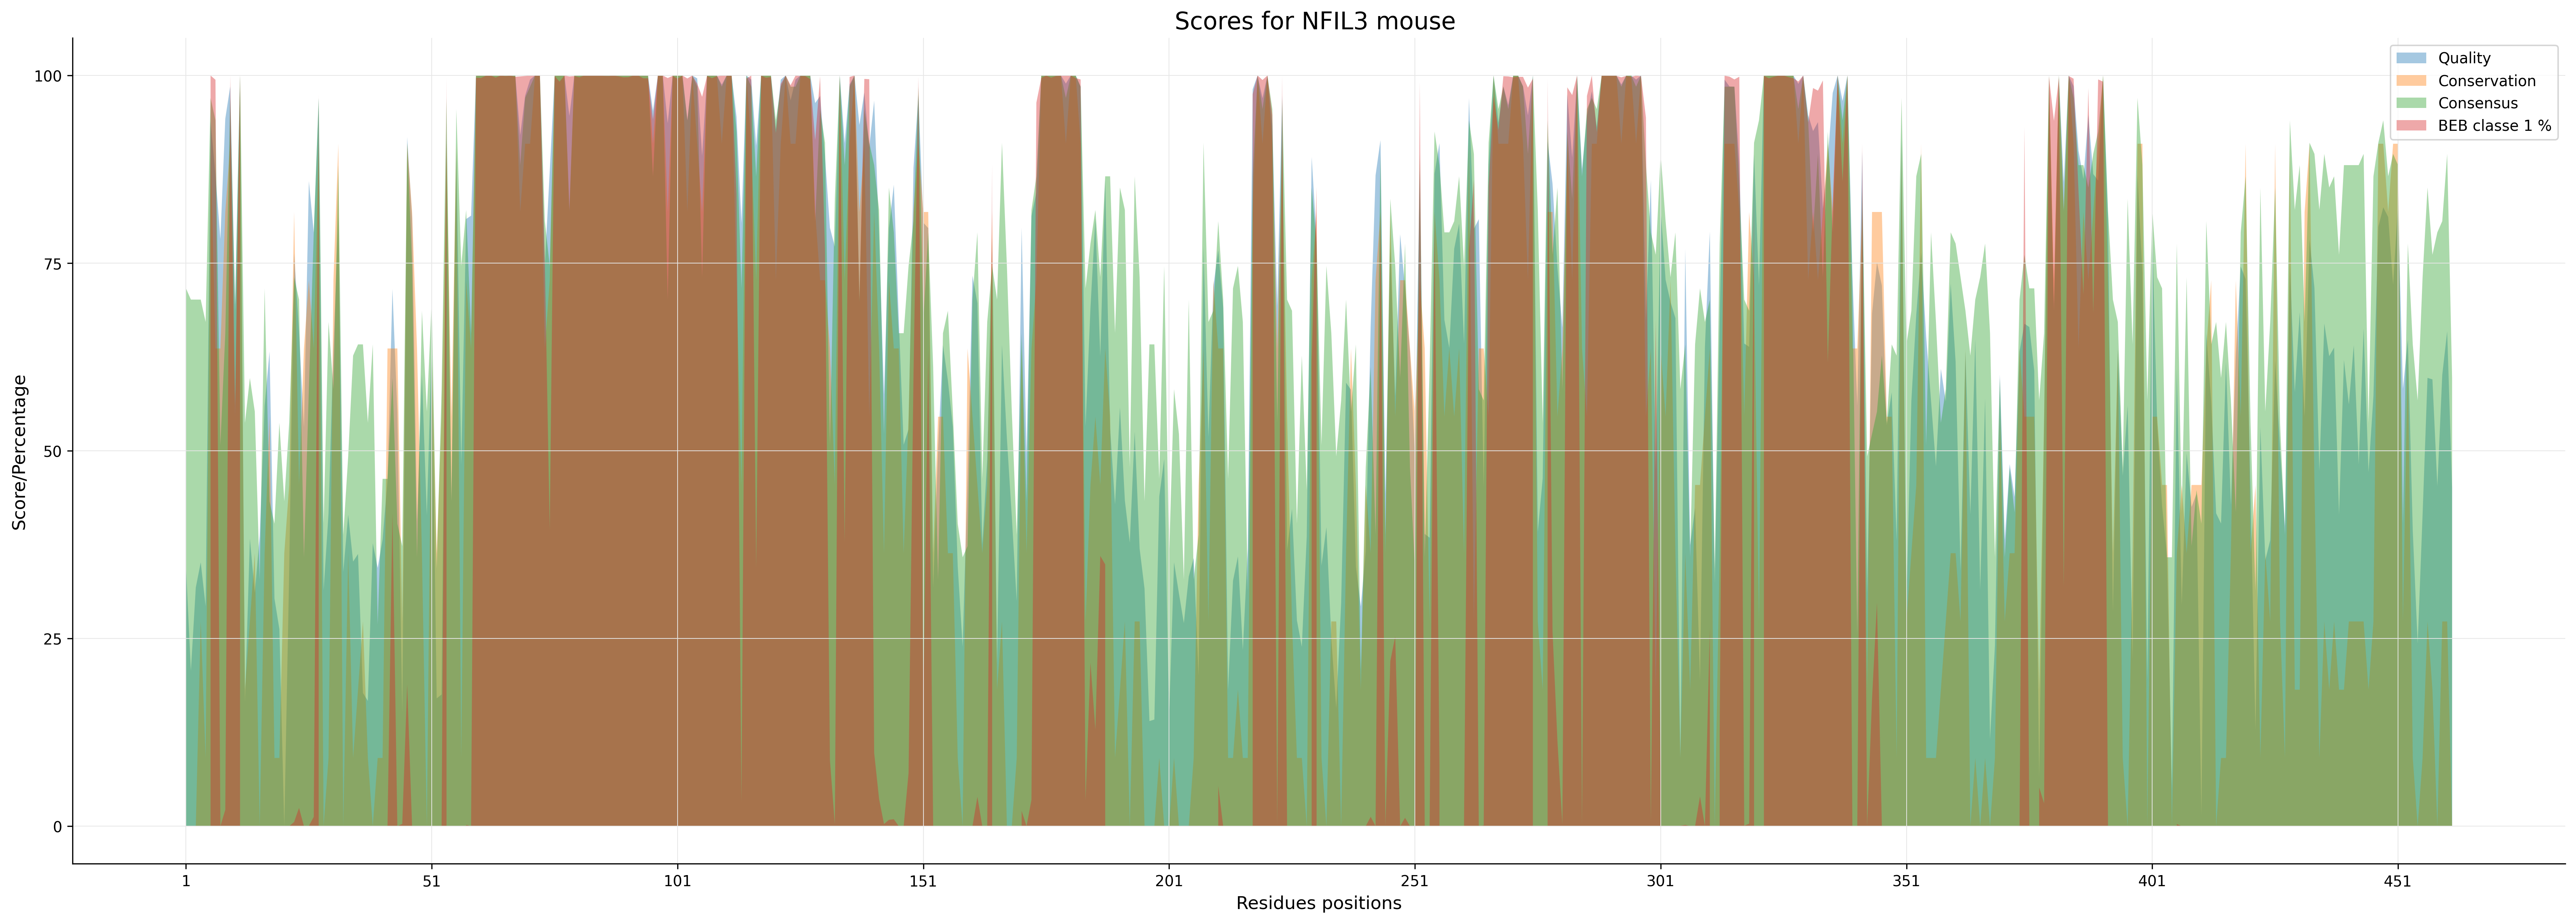

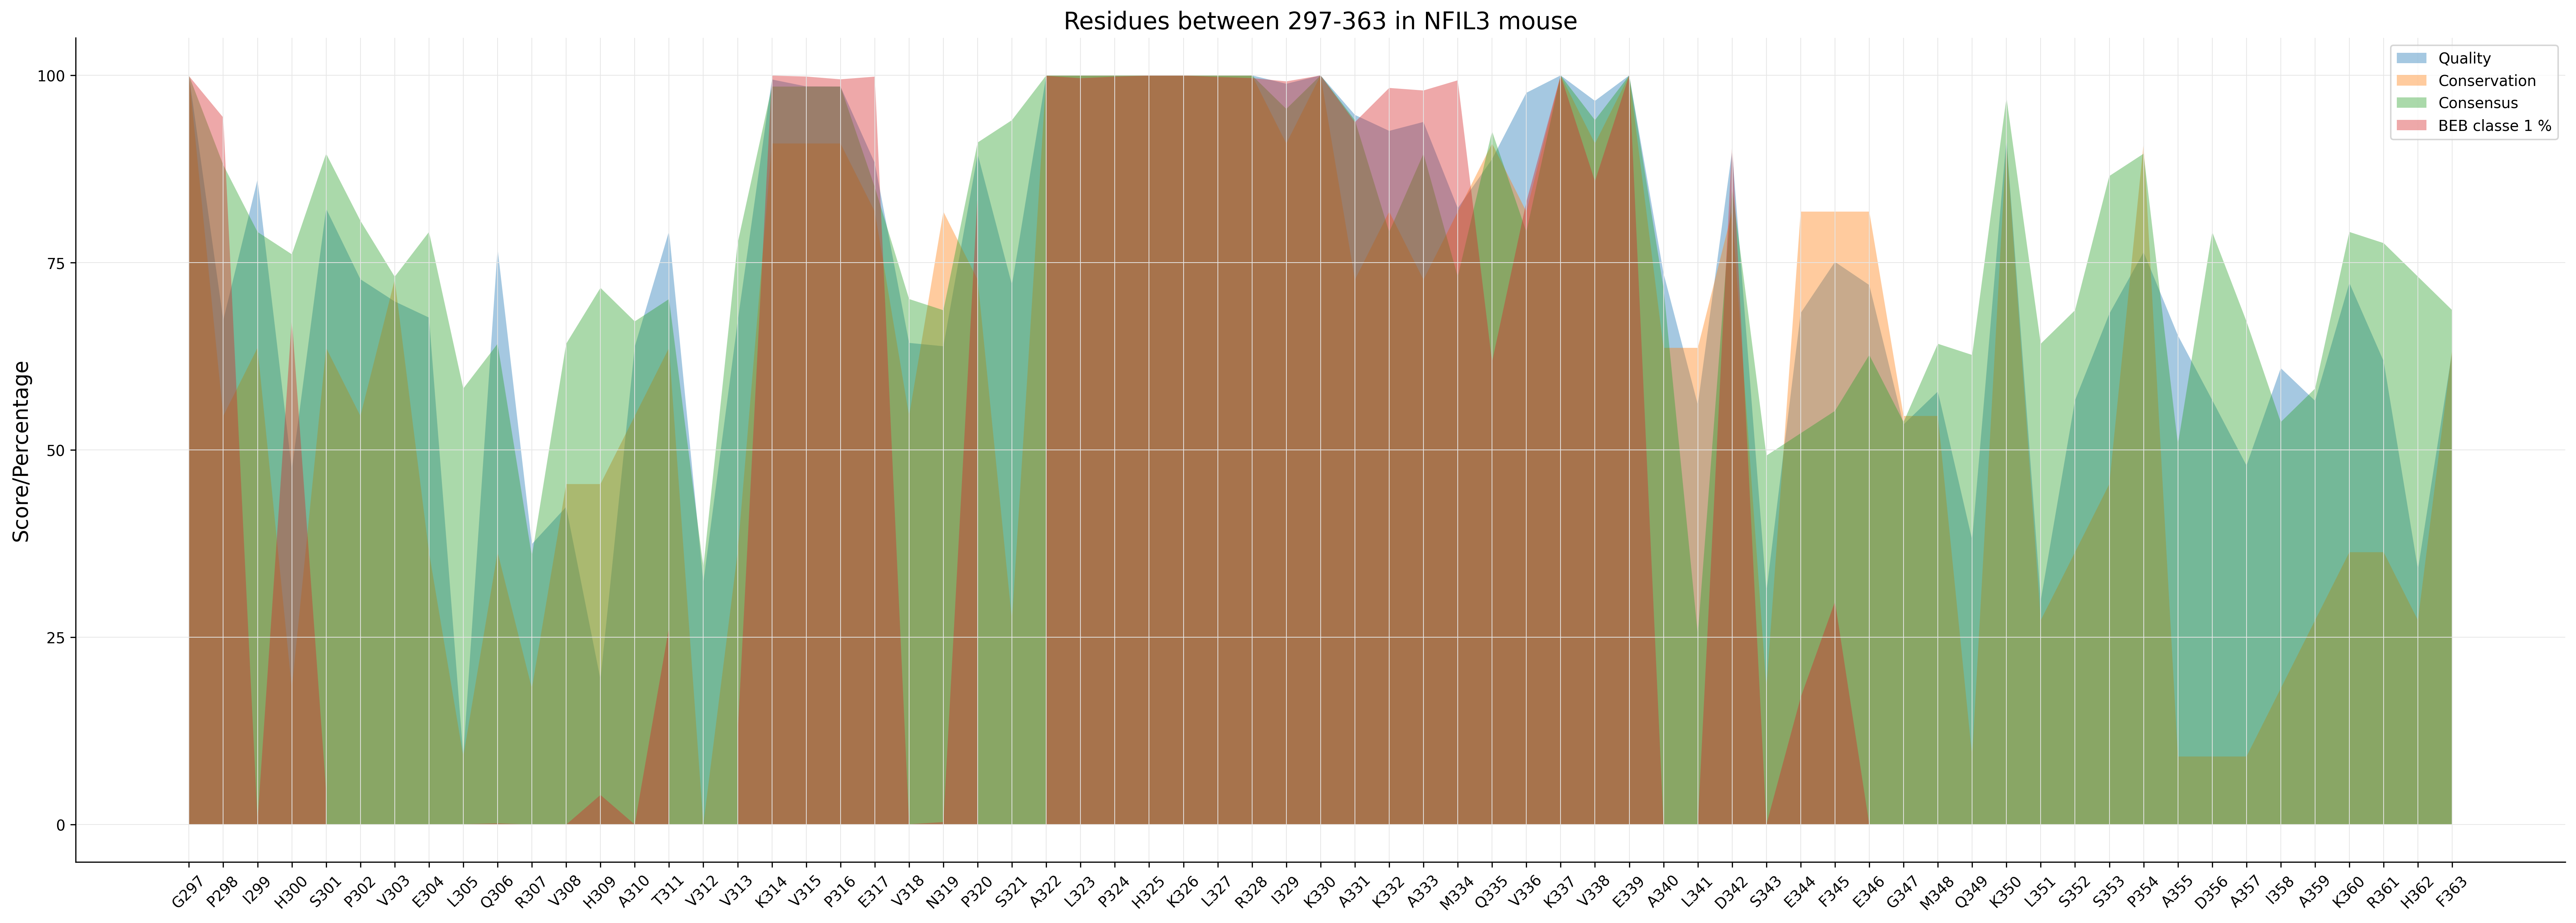

In [24]:
# Names of the headers to include in the graph
# NOTE: Between the names please insert a space after the coma: ", "
name = "Quality, Conservation, Consensus, BEB classe 1"

plot_all(df_all, name, save_path, "fill")
plot_zoom(df_all, name, save_path, 297, 363, "fill")

#### Plot Postmean w

In [16]:
def plot_postmean(df, save_path, zoom=False, seq_begin=1, seq_end=462, save="png"):
    """
    Plot the Postmean omega values of a DataFrame along with their standard deviations.
    The function is able to do this only in specific rows (zoom).
    
    Parameters:
        - df (DataFrame): Dataframe containing the values to be plotted
        - save_path (str): Path to the plot backup
        - zoom (bool): Zoomed or unzoomed graphic
        - seq_begin (int): First line to plot
        - seq_end (int): Last line to plot
        - save (str): File plot format (PDF or PNG)
    """
    
    if zoom == False:
        # Setting the variables for the plot
        all_res = []
        all_res.extend(df["Position"])
        xmin, xmax = min(all_res), max(all_res)
        
        # Plot
        plt.figure(figsize=(30, 10), dpi=300)
        plt.errorbar(df["Position"], df["Postmean W"], yerr=df["sd W"], fmt="o", capsize=5)
        plt.title("Postmean omega in NFIL3 mouse\n", fontsize=16)
        plt.grid(color="0.9", linestyle="-", linewidth=0.5)
        plt.gca().spines["top"].set_visible(False)
        plt.gca().spines["right"].set_visible(False)
        plt.xticks(np.arange(xmin, xmax + 1, 50))
        plt.xlim(-10, 475)
        plt.ylim(0, 1)
        plt.xlabel("Residues positions", fontsize=12)
        plt.ylabel("Score", fontsize=12)
        plt.savefig(f"{save_path}/PostmeanW.{save}", dpi=300)           
        plt.show()

    elif zoom == True:      
        # Setting the variables for the plot
        x = range(len(df["Position"][seq_begin-1:seq_end]))
        df["Name_Position"] = df["Name"] + df["Position"].astype(str)

        # Plot
        plt.figure(figsize=(30, 10), dpi=300)
        plt.errorbar(x, df["Postmean W"][seq_begin-1:seq_end], yerr=df["sd W"][seq_begin-1:seq_end], fmt="o", capsize=5)
        plt.title(f"Postmean omega for residues between {seq_begin}-{seq_end} in NFIL3 mouse\n", fontsize=16)
        plt.grid(color="0.9", linestyle="-", linewidth=0.5)
        plt.gca().spines["top"].set_visible(False)
        plt.gca().spines["right"].set_visible(False)
        plt.xticks(x, df["Name_Position"][seq_begin-1:seq_end])
        plt.xticks(rotation=45)
        plt.ylim(0, 1)
        plt.ylabel("Score", fontsize=12)
        plt.savefig(f"{save_path}/PostmeanW_{seq_begin}_{seq_end}.{save}", dpi=300)
        plt.show()

    else:
        print("The 'zoom' parameter must be set to 'True' for a zoomed-in graph, otherwise, it should be set to 'False' (default).")


In [17]:
def plot_postmean_BEB(df, save_path, proba, zoom=False, seq_begin=1, seq_end=462, save="png"):
    """
    Plot the Postmean omega values of a DataFrame along with their standard deviations and the BEB probalilites for class 1.
    The function is able to do this only in specific rows (zoom).
    
    Parameters:
        - df (DataFrame): Dataframe containing the values to be plotted
        - save_path (str): Path to the plot backup
        - proba (float): BEB probalilites for class 1 to show
        - zoom (bool): Zoomed or unzoomed graphic
        - seq_begin (int): First line to plot
        - seq_end (int): Last line to plot
        - save (str): File plot format (PDF or PNG)
    """
    
    # Filtering which points to display
    mask = df["BEB classe 1"] >= proba
    y_top = 0.90
    
    if zoom == False:
        # Setting the variables for the plot
        all_res = []
        all_res.extend(df["Position"])
        xmin, xmax = min(all_res), max(all_res)
        
        # Plot
        plt.figure(figsize=(30, 10), dpi=300)
        plt.errorbar(df["Position"], df["Postmean W"], yerr=df["sd W"], fmt="o", capsize=5)
        plt.scatter(df.loc[mask, "Position"], [y_top] * mask.sum(), marker="$*$", s=50, zorder=3, c="black", label=f"BEB proba class 1 >= {proba}")
        plt.title("Postmean omega in NFIL3 mouse\n", fontsize=16)
        plt.grid(color="0.9", linestyle="-", linewidth=0.5)
        plt.gca().spines["top"].set_visible(False)
        plt.gca().spines["right"].set_visible(False)
        plt.xticks(np.arange(xmin, xmax + 1, 50))
        plt.xlim(-10, 475)
        plt.ylim(0, 1)
        plt.xlabel("Residues positions", fontsize=12)
        plt.ylabel("Score", fontsize=12)
        plt.legend()
        plt.savefig(f"{save_path}/PostmeanW_BEB.{save}", dpi=300)            
        plt.show()

    elif zoom == True:      
        # Setting the variables for the plot
        df["Name_Position"] = df["Name"] + df["Position"].astype(str)
        mask_zoom = (df["Position"] >= seq_begin) & (df["Position"] <= seq_end)
        mask_combined = mask_zoom & mask

        # Plot
        plt.figure(figsize=(30, 10), dpi=300)
        plt.errorbar(df["Position"][mask_zoom], df["Postmean W"][mask_zoom], yerr=df["sd W"][mask_zoom], fmt="o", capsize=5, label="Postmean omega")
        plt.scatter(df.loc[mask_combined, "Position"], [y_top] * mask_combined.sum(), marker="$*$", s=50, zorder=3, c="black", label=f"BEB proba class 1>= {proba}")
        plt.title(f"Postmean omega for residues between {seq_begin}-{seq_end} in NFIL3 mouse\n", fontsize=16)
        plt.grid(color="0.9", linestyle="-", linewidth=0.5)
        plt.gca().spines["top"].set_visible(False)
        plt.gca().spines["right"].set_visible(False)
        plt.xticks(df.loc[mask_zoom, "Position"], df.loc[mask_zoom, "Name_Position"])
        plt.xticks(rotation=45)
        plt.ylim(0, 1)
        plt.ylabel("Score", fontsize=12)
        plt.legend()
        plt.savefig(f"{save_path}/PostmeanW_BEB_{seq_begin}_{seq_end}.{save}", dpi=300)  
        plt.show()

    else:
        print("The 'zoom' parameter must be set to 'True' for a zoomed-in graph, otherwise, it should be set to 'False' (default).")


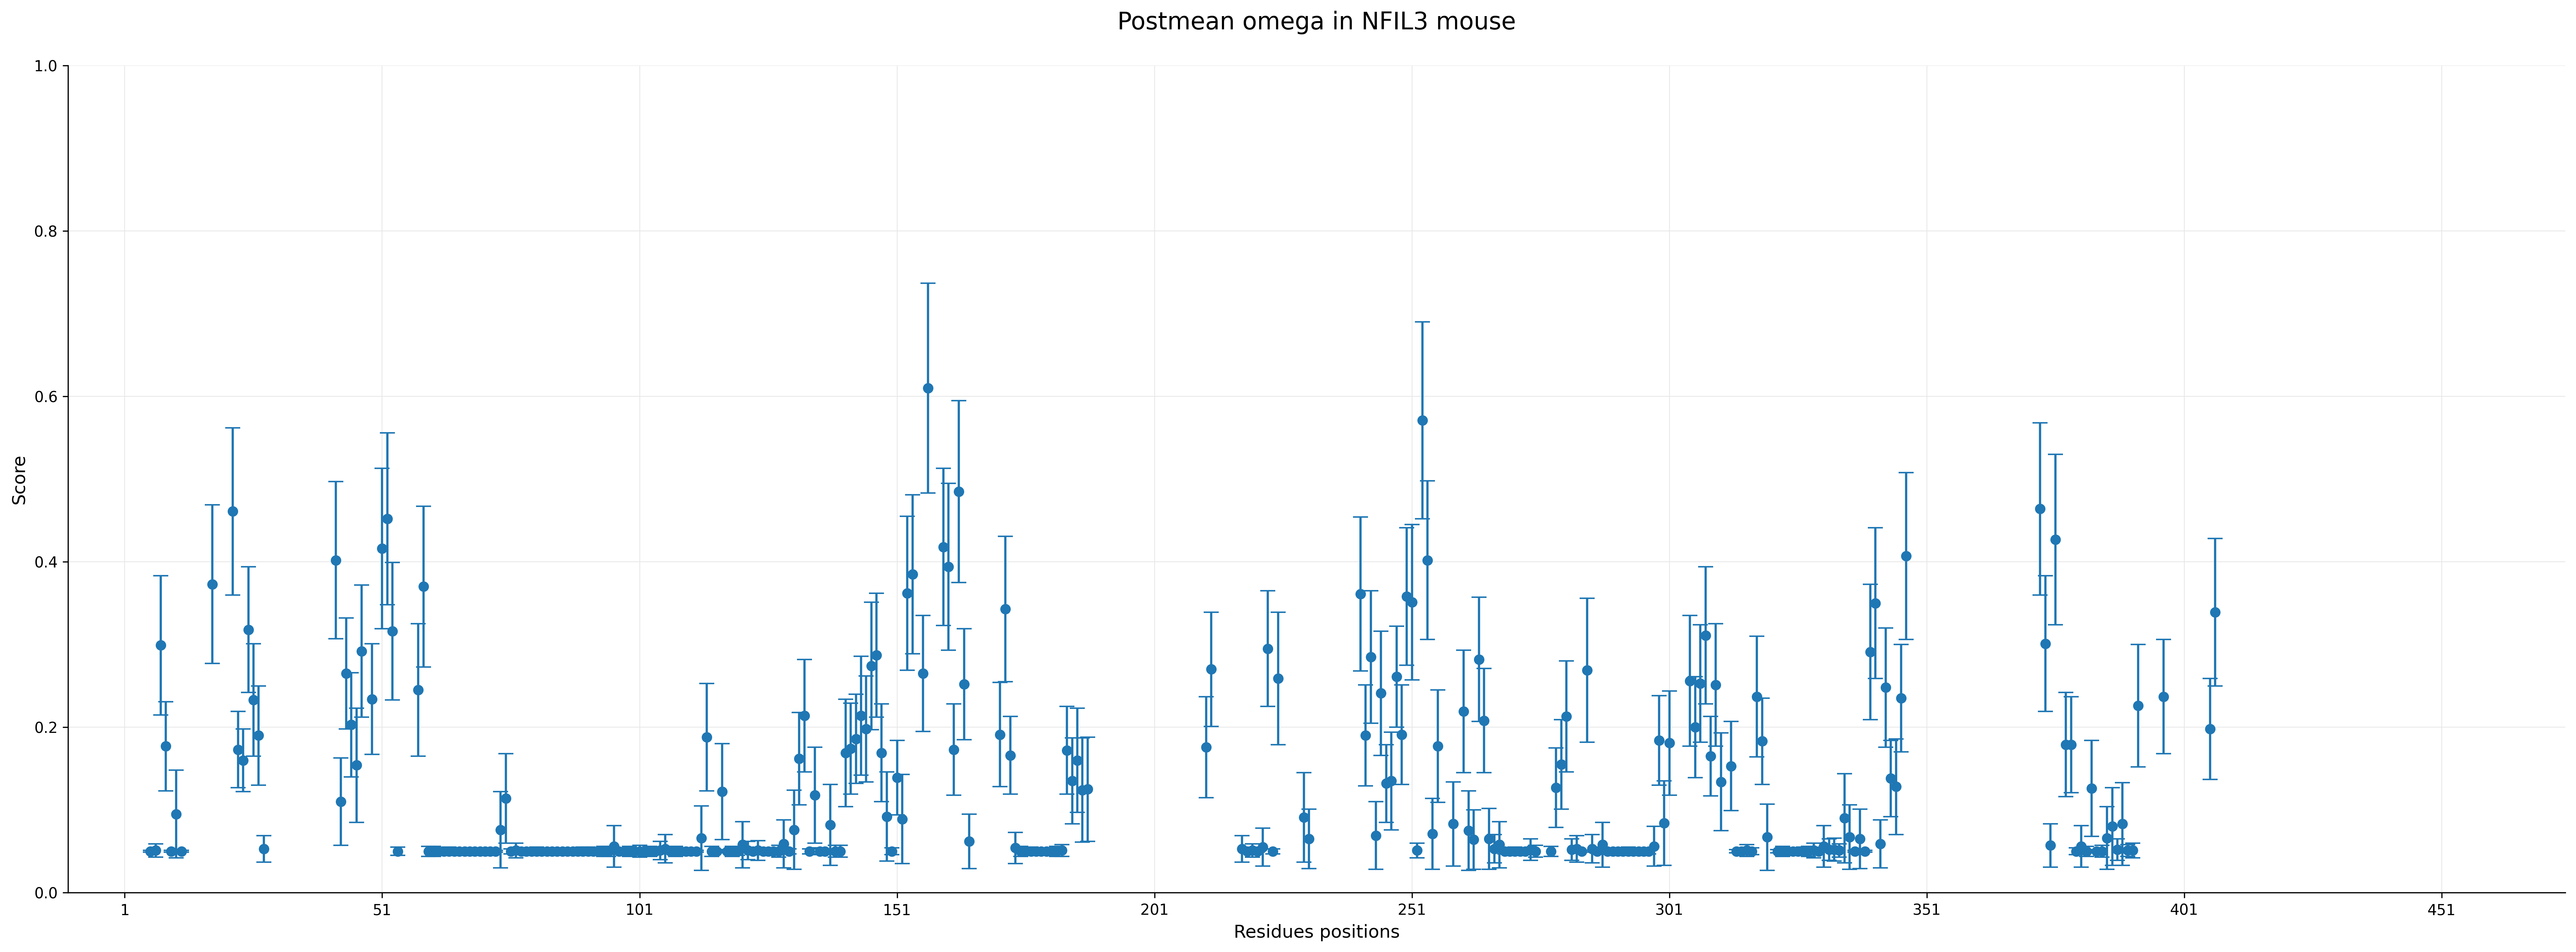

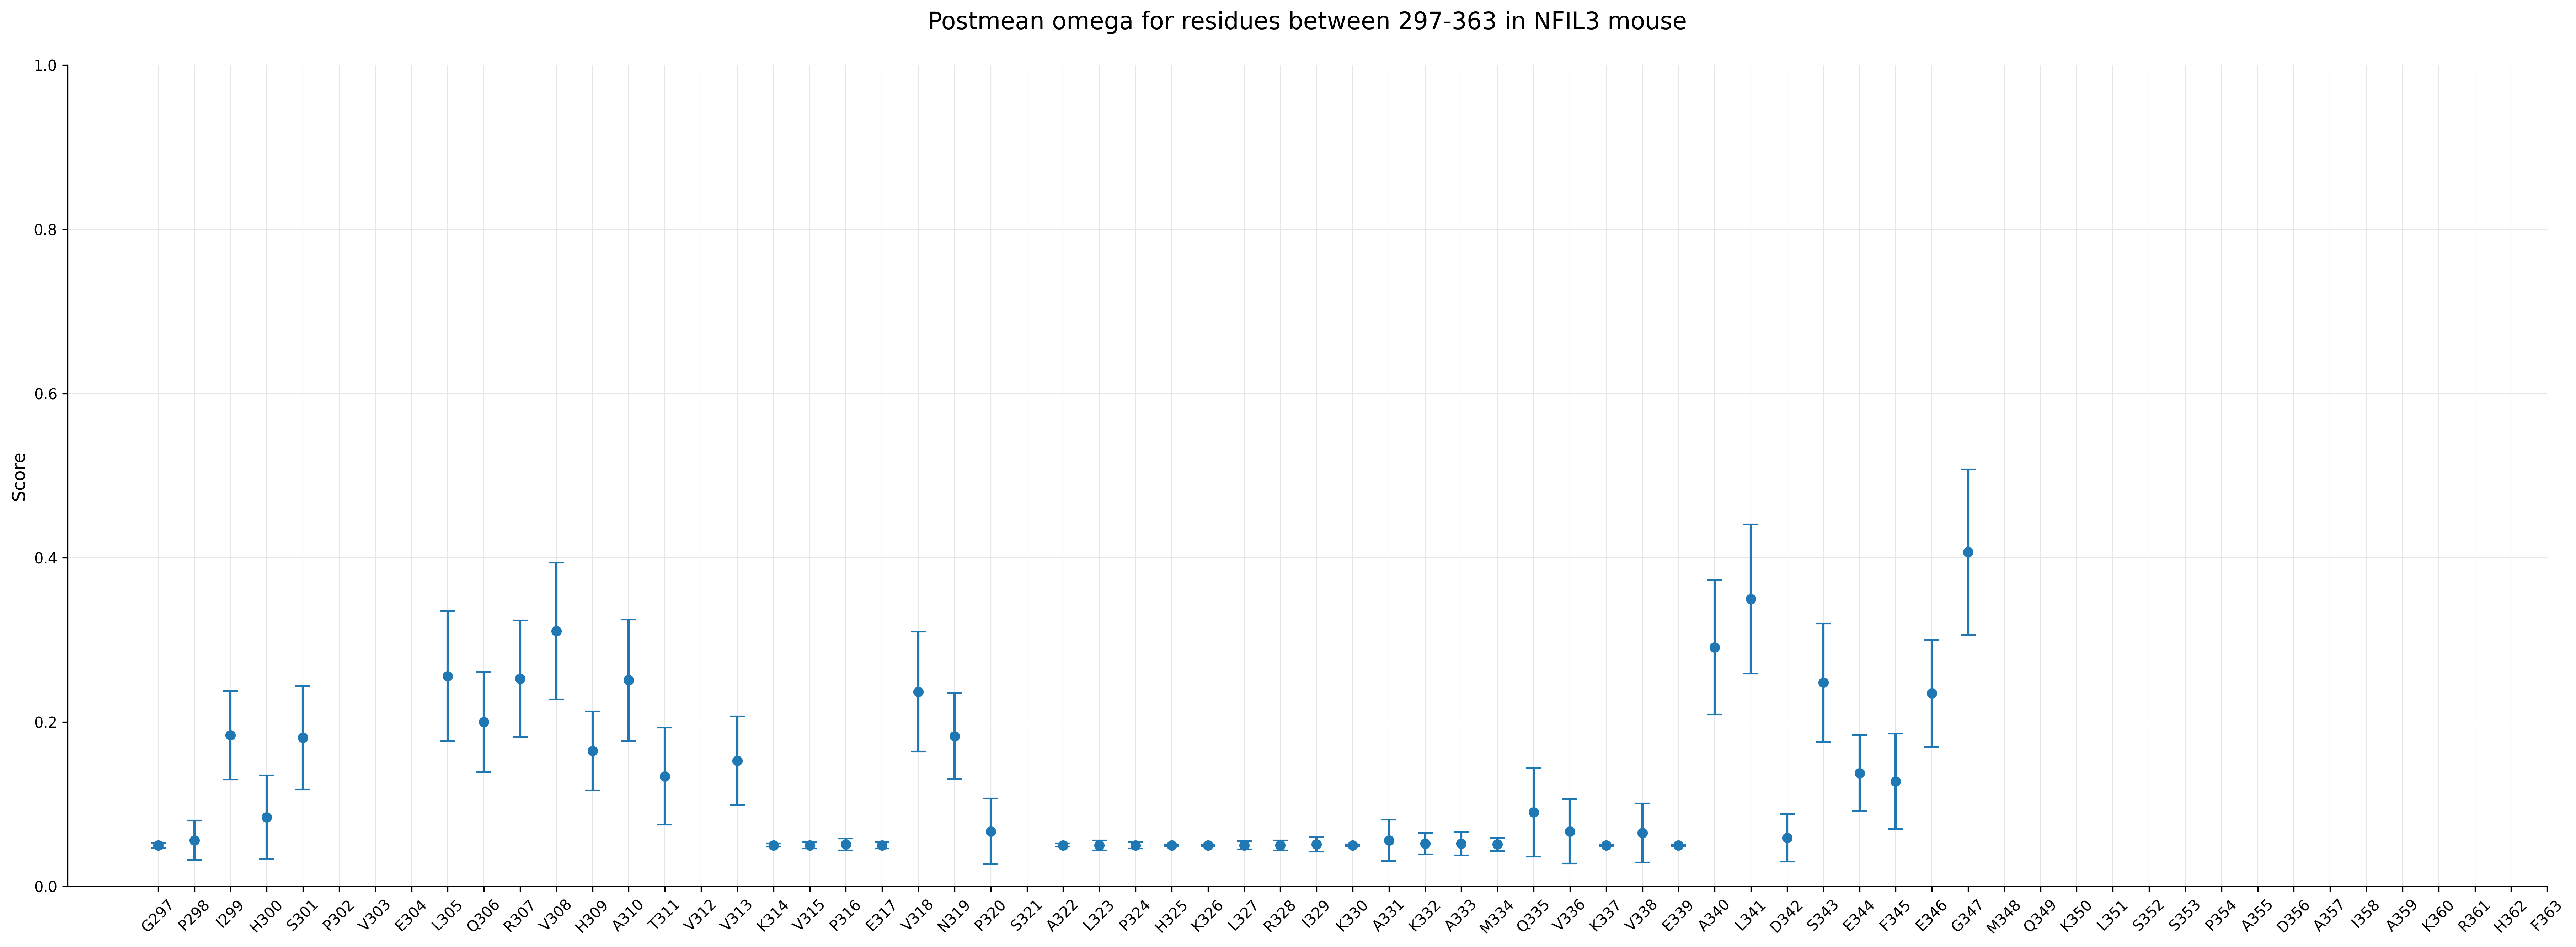

In [18]:
plot_postmean(df_all, save_path)
plot_postmean(df_all, save_path,zoom=True, seq_begin=297, seq_end=363)

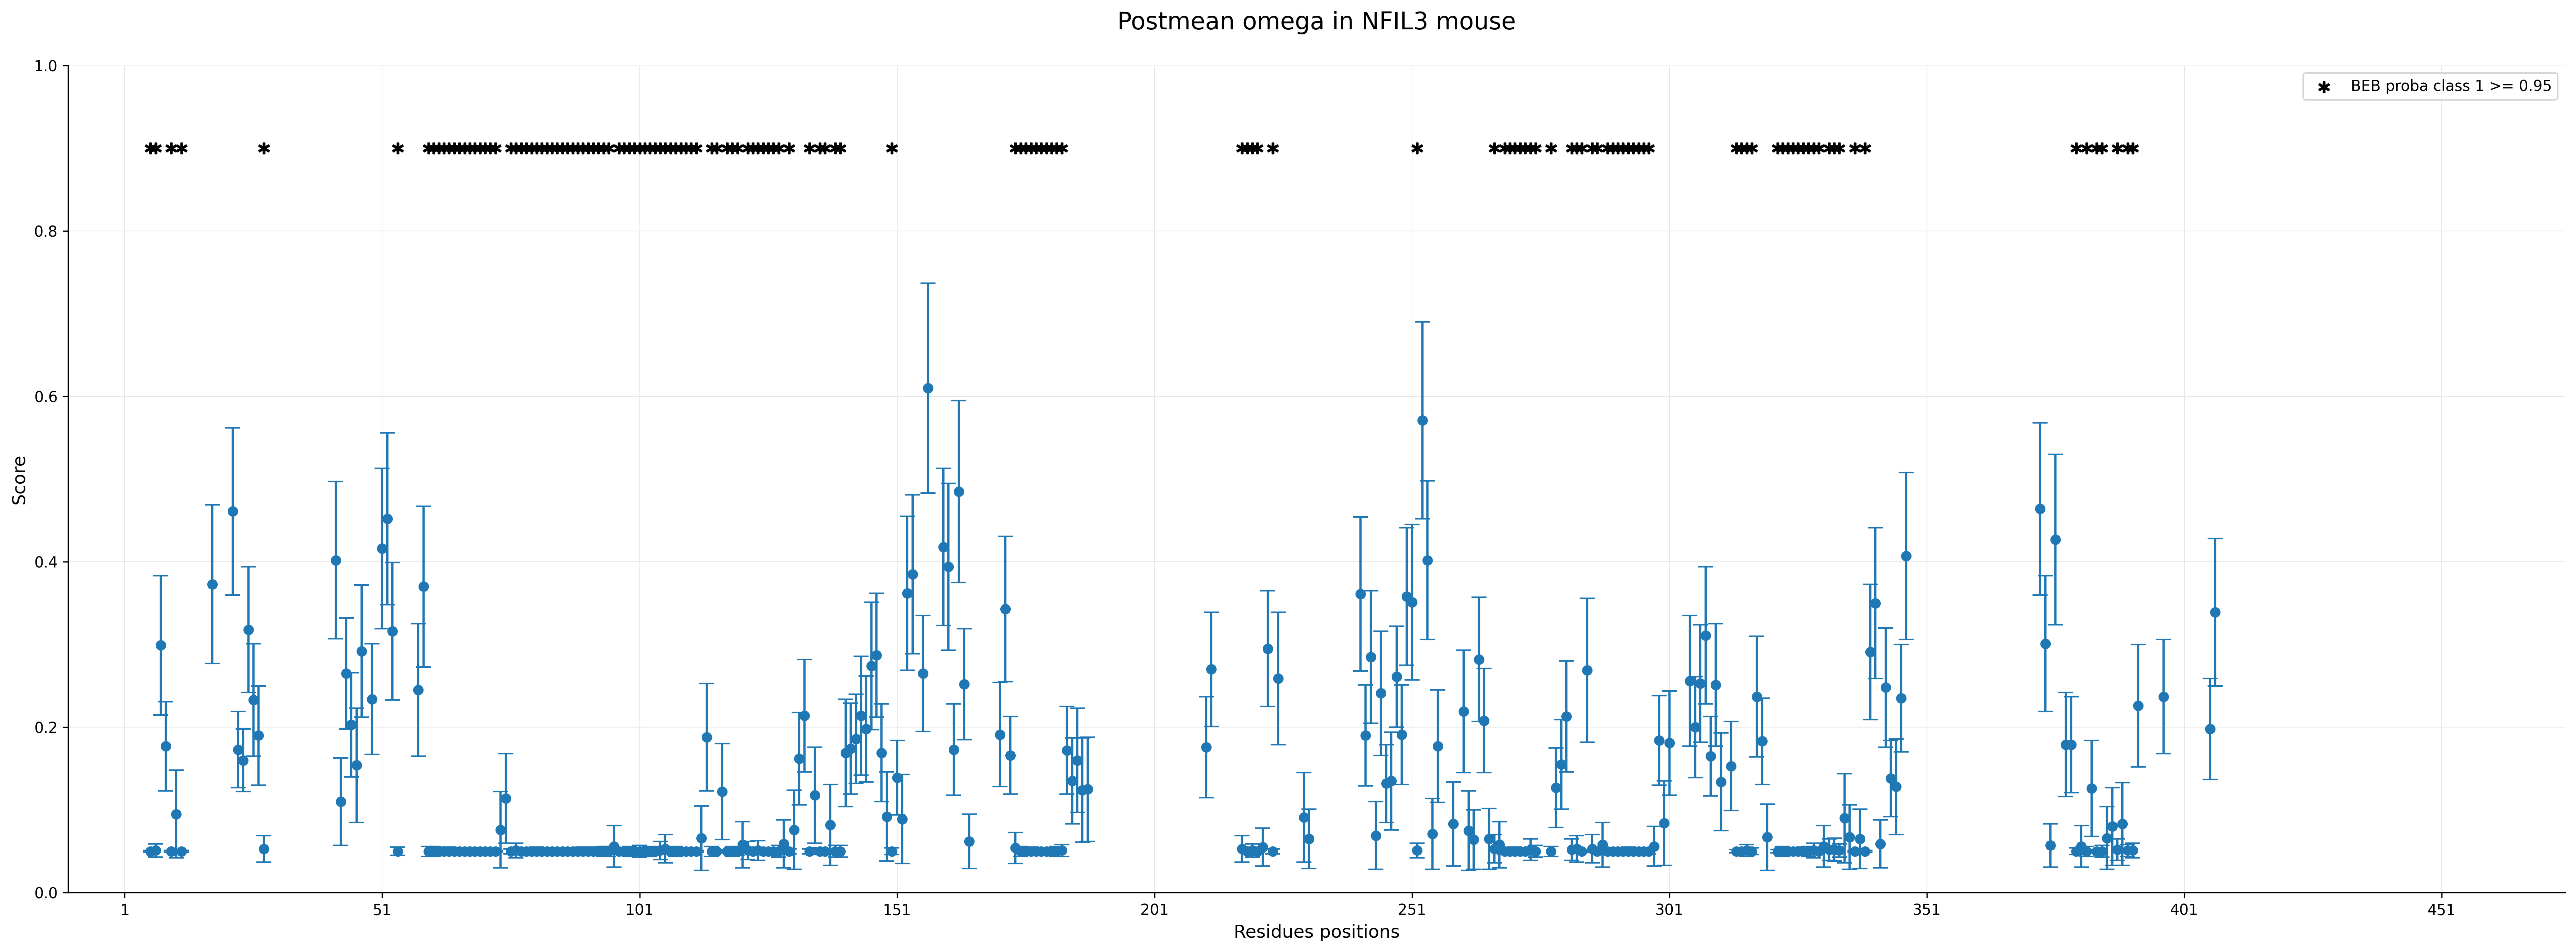

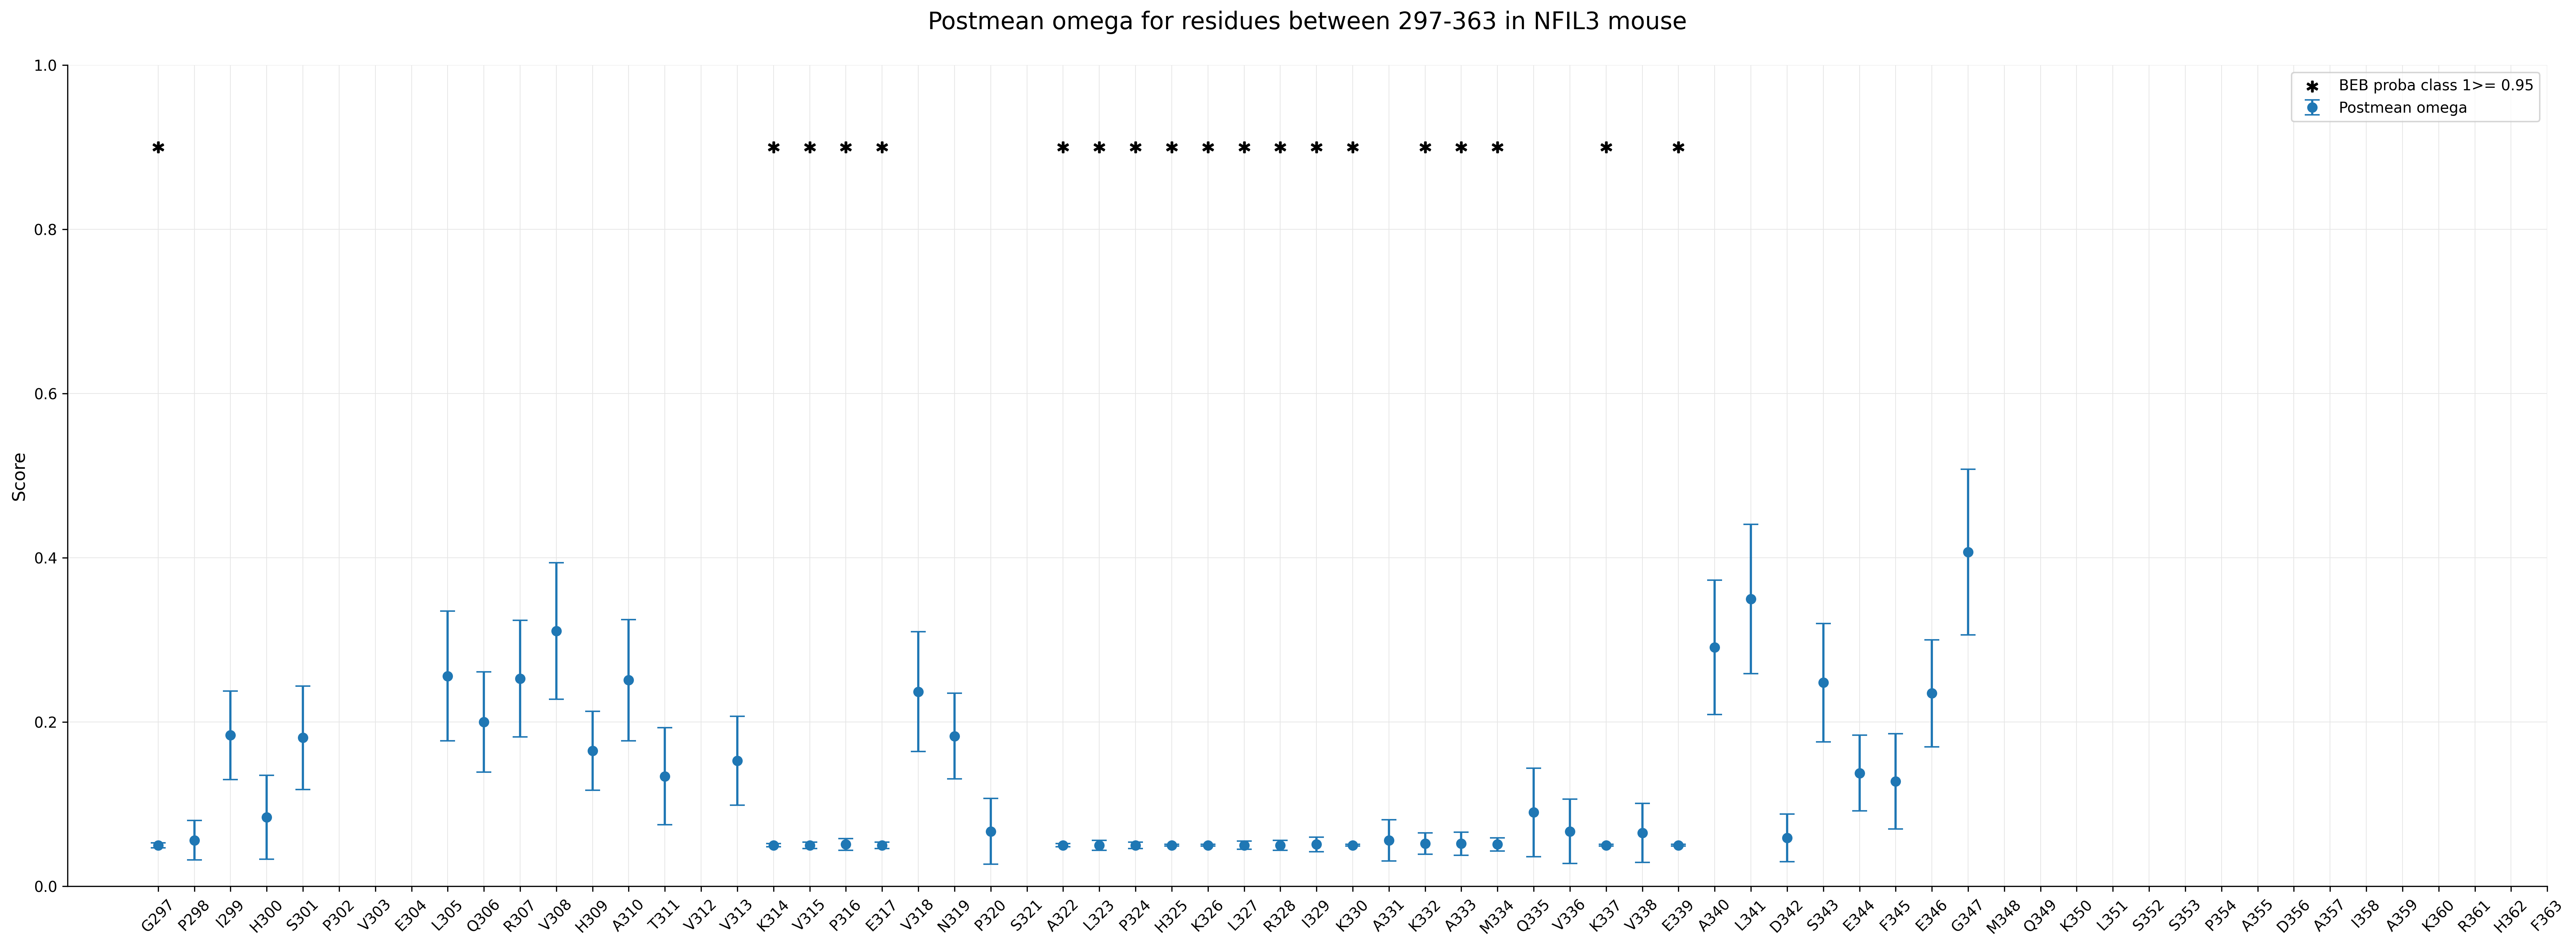

In [19]:
plot_postmean_BEB(df_all, save_path, 0.95)
plot_postmean_BEB(df_all, save_path, 0.95, zoom=True, seq_begin=297, seq_end=363)

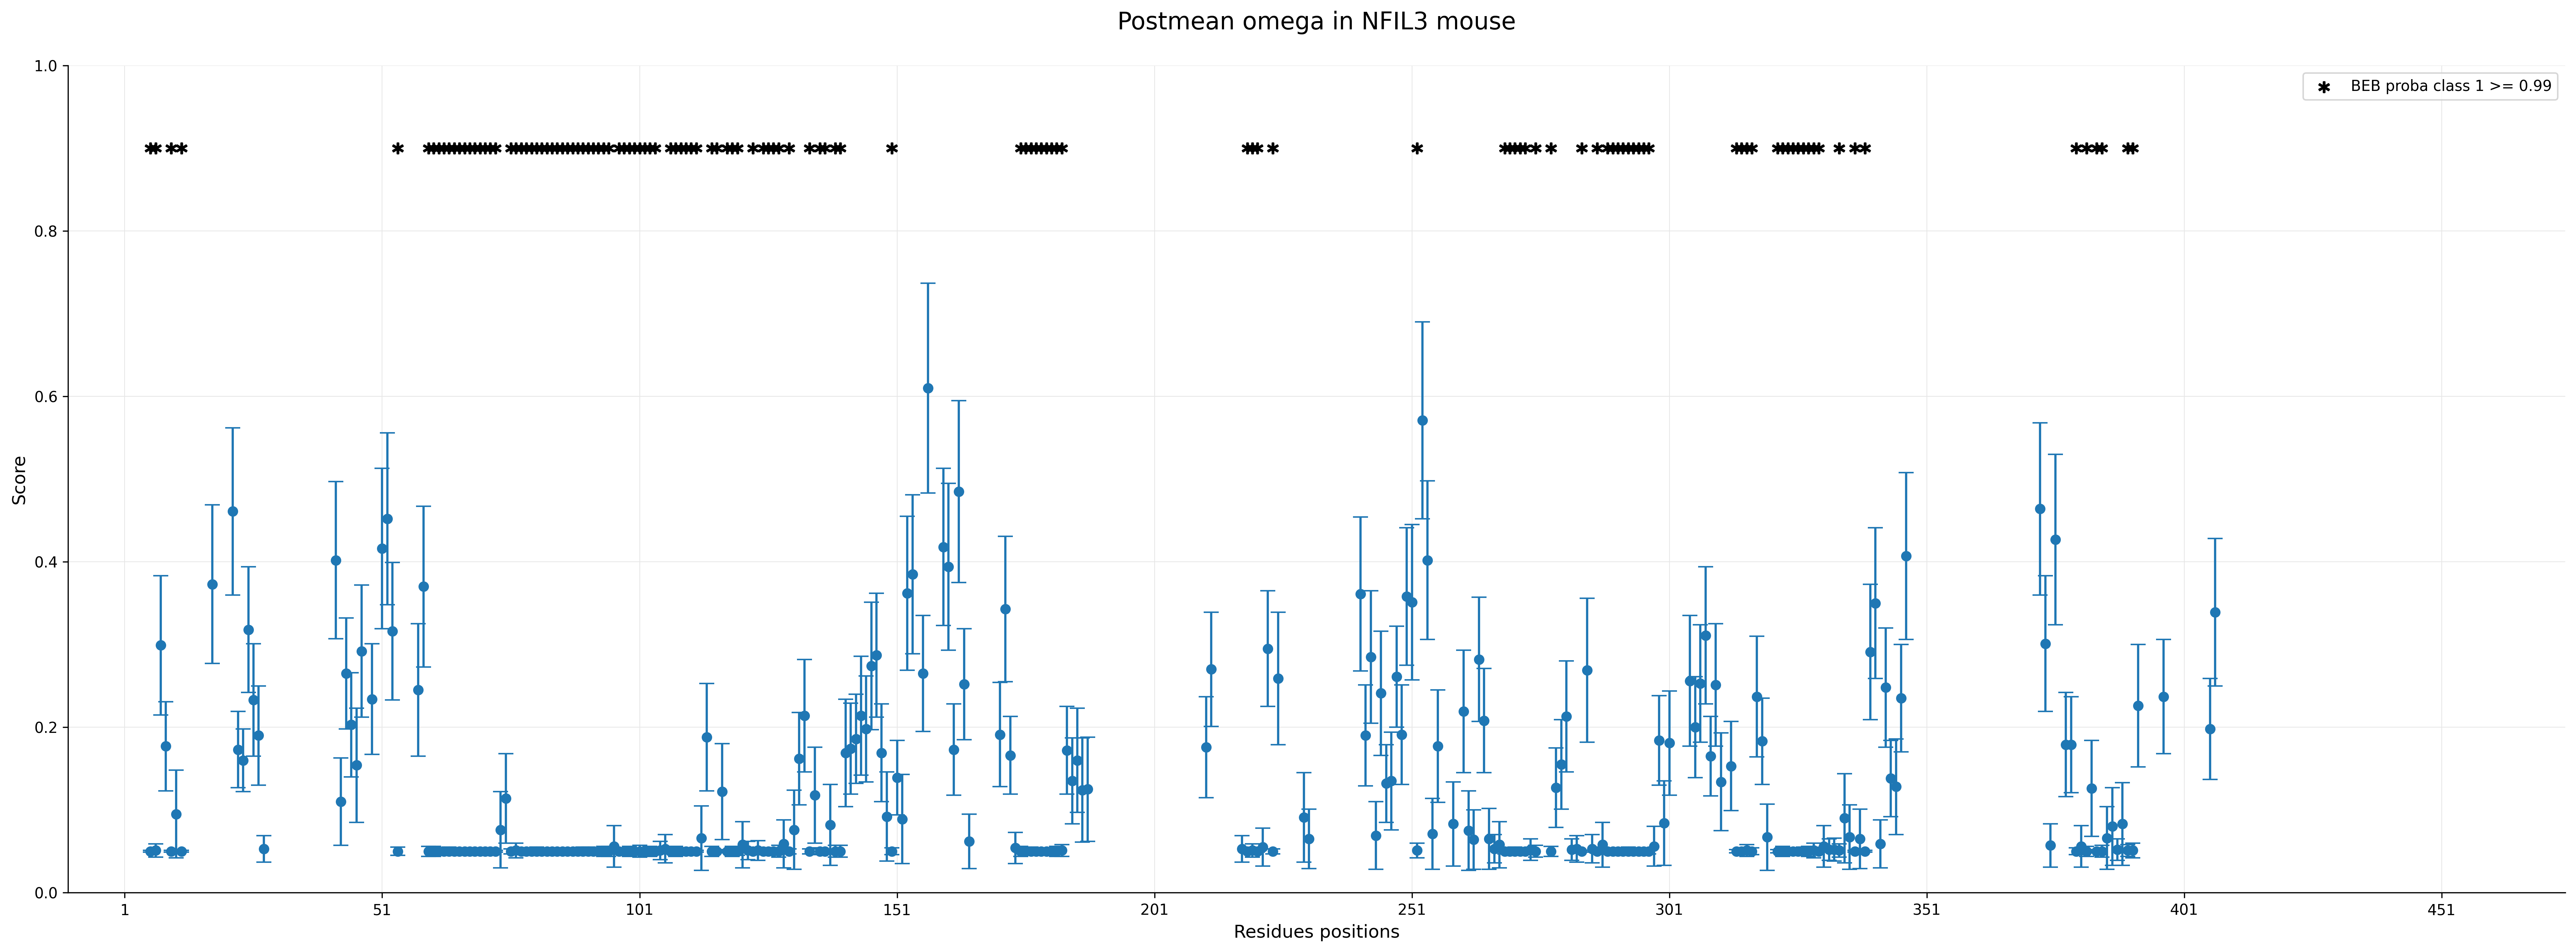

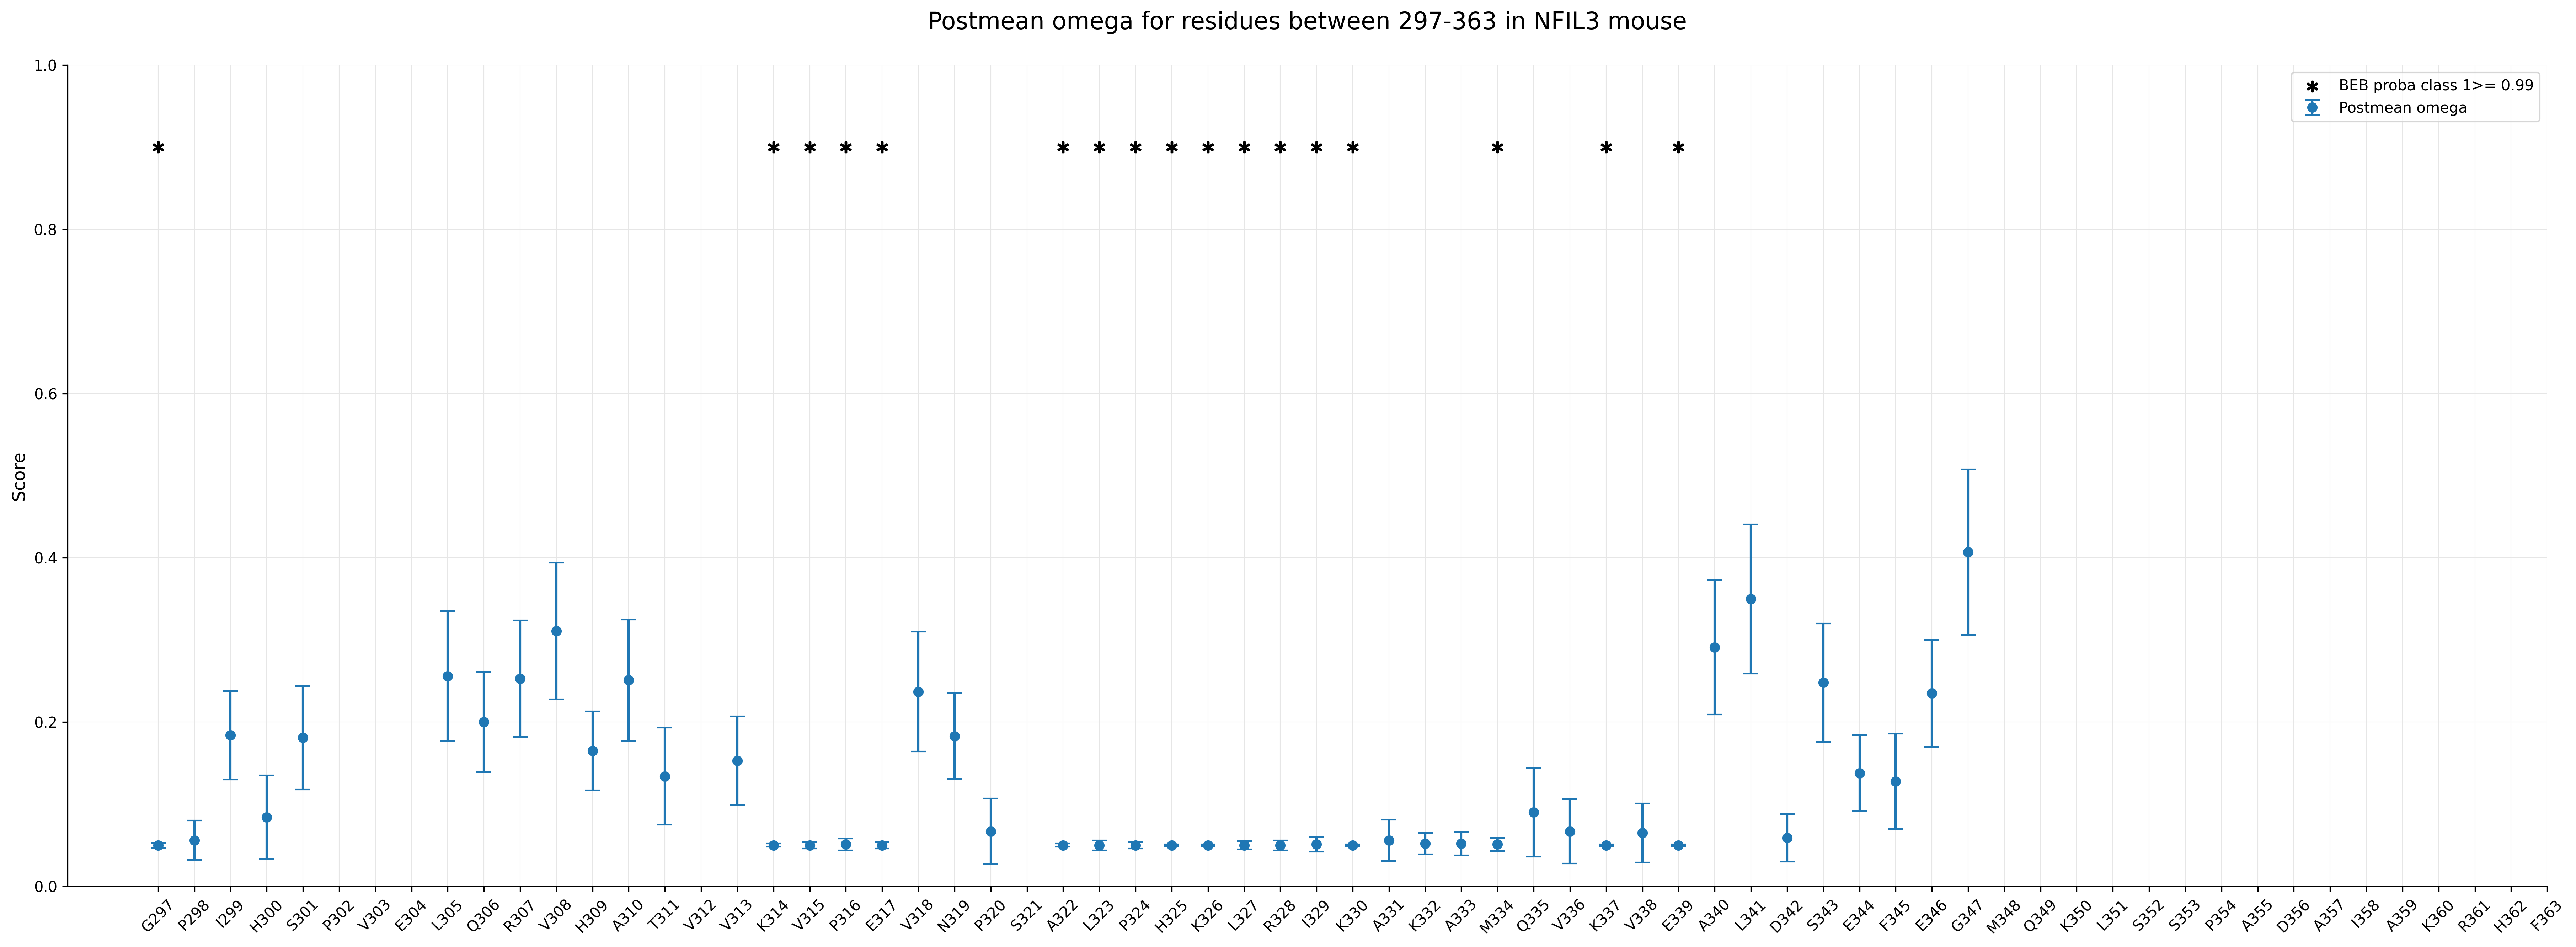

In [20]:
plot_postmean_BEB(df_all, save_path, 0.99)
plot_postmean_BEB(df_all, save_path, 0.99, zoom=True, seq_begin=297, seq_end=363)